# Fruit Object Detection

![](http://)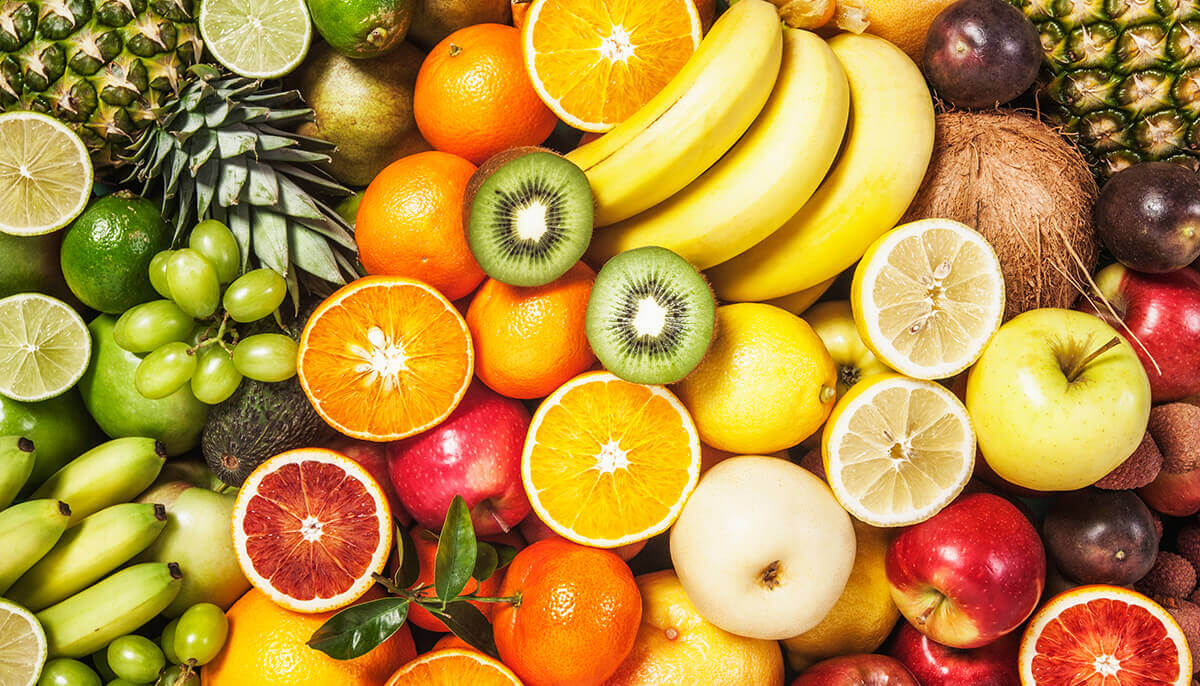

In [31]:
from IPython import display
display.clear_output()

!pip install ultralytics

In [32]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import torch.nn as nn
import torch
from torchvision import transforms, datasets
from PIL import Image, ImageDraw, ImageFont
from torch.utils.data import Dataset, DataLoader
from ultralytics import YOLO
from IPython import display
import random

In [33]:
#activate gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Prepare datasets

In [34]:
#dirs
data = '/kaggle/input/datasets/shokhjahonisroilov/mini-set-fruits' 

traindir    = os.path.join(data, 'train/images')
trainlabels = os.path.join(data,'train/labels') 

valdir    = os.path.join(data,'test/images') 
vallabels = os.path.join(data,'test/labels' )

In [35]:
print(os.path.exists(traindir))

True


In [36]:
traindir

'/kaggle/input/datasets/shokhjahonisroilov/mini-set-fruits/train/images'

In [37]:
def files(images, labels):
    image_files = glob.glob(os.path.join(images, '*.jpg'))
    labels_files = glob.glob(os.path.join(labels,  '*.txt'))
    
    return image_files, labels_files

In [38]:
#files
train_image_files, train_labels_files = files(traindir, trainlabels)
val_image_files, val_labels_files = files(valdir, vallabels)

train_image_files.sort()
train_labels_files.sort()
val_image_files.sort()
val_labels_files.sort()

In [39]:
print(len(train_image_files), len(train_labels_files))

540 540


In [40]:
import os
from PIL import Image, ImageDraw
from torch.utils.data import Dataset

class FruitDataset(Dataset):
    def __init__(self, image_paths, label_paths, classes, colors, transform=None, draw_box=False):
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.transform = transform
        self.draw_box = draw_box
        self.classes = classes
        self.colors = colors
        
    def __getitem__(self, index):
        image_path = self.image_paths[index]
        label_path = self.label_paths[index]
        
        # 1. Open image and get its real dimensions
        image = Image.open(image_path).convert("RGB")
        img_w, img_h = image.size 
        
        labels = []
        
        # 2. Only initialize drawing context if draw_box is True
        draw = ImageDraw.Draw(image) if self.draw_box else None

        if os.path.exists(label_path):
            with open(label_path, 'r') as file:
                for line in file:
                    parts = line.strip().split()
                    if not parts: continue

                    # The first number is the class ID
                    class_num = int(parts[0])
                    
                    # 3. FIX: Handle the multiple x,y pairs (Polygons)
                    # We extract every odd index for X and every even for Y
                    coords = list(map(float, parts[1:]))
                    xs = coords[0::2] 
                    ys = coords[1::2] 

                    if not xs or not ys: continue

                    # 4. Find the "extremes" to build a bounding box
                    x_min = int(min(xs) * img_w)
                    y_min = int(min(ys) * img_h)
                    x_max = int(max(xs) * img_w)
                    y_max = int(max(ys) * img_h)

                    labels.append((class_num, x_min, y_min, x_max, y_max))

                    # 5. Drawing logic (using the class-level colors/classes)
                    if self.draw_box and draw:
                        clr = self.colors[class_num % len(self.colors)]
                        draw.rectangle([x_min, y_min, x_max, y_max], outline=clr, width=5)
                        draw.text((x_min, y_min - 10), self.classes[class_num], fill='white')

        # 6. Apply transforms AFTER drawing so boxes are baked in
        if self.transform:
            image = self.transform(image)

        return image, labels
            
    def __len__(self):
        return len(self.image_paths)

In [41]:
train_dataset = FruitDataset(train_image_files, train_labels_files, None, True)
val_dataset = FruitDataset(val_image_files, val_labels_files, None, False)

# Show some images with its labels and box

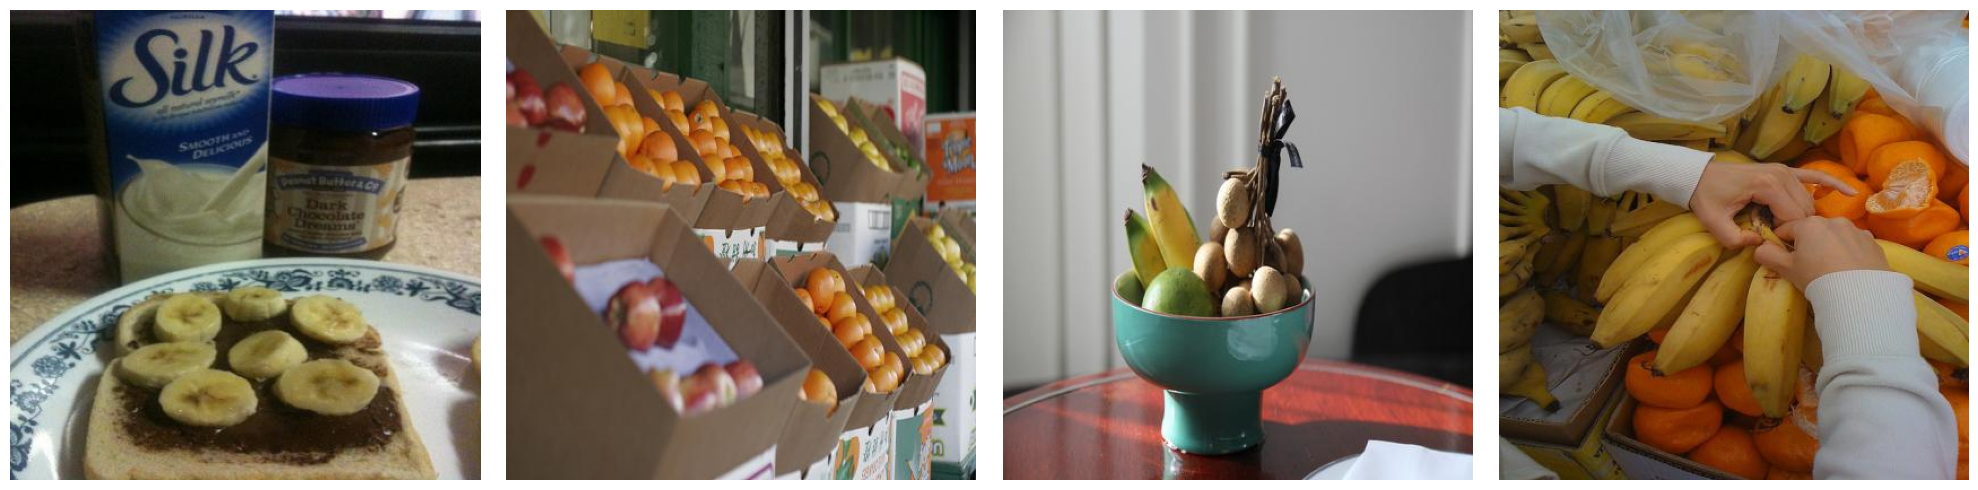

In [42]:
import matplotlib.pyplot as plt

# 1. Define your indices
indxs = [i for i in range(1, 5)] 

# 2. Create subplots based EXACTLY on the number of indices you want to show
fig, axes = plt.subplots(1, len(indxs), figsize=(20, 5))

# 3. Use enumerate to get both the 'counter' (0, 1, 2...) and the 'dataset index'
for i, img_idx in enumerate(indxs):
    image, labels = train_dataset[img_idx]
    
    # Check if the image is a PyTorch Tensor (C, H, W) 
    # and permute it to (H, W, C) for matplotlib
    if hasattr(image, 'permute'):
        image = image.permute(1, 2, 0)
        
    axes[i].imshow(image)
    axes[i].axis('off')
    
plt.tight_layout() # Prevents overlapping labels/axes
plt.show()

# Training and validation

In [43]:
model = YOLO('yolov8n.pt')

In [44]:
import yaml
from pathlib import Path
import wandb
wandb.init(mode='disabled')


data = {
    'train': "/kaggle/input/fruit-detection/Fruits-detection/train",
    'val': "/kaggle/input/fruit-detection/Fruits-detection/test",
    'nc': 2,  
    'names' : 
        ['Apple',
         'Banana']
}

with open('data.yaml', 'w') as file:
    yaml.dump(data, file)

yaml_path = 'data.yaml'

#os.system('python train.py --img 512 --batch 16 --epochs 20 --data data.yaml --weights yolov8s.pt')
model.train(data=yaml_path, imgsz=512, batch=32, epochs=20)

Ultralytics 8.4.14 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c81b07abd60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [45]:
model.val(data=yaml_path)

Ultralytics 8.4.14 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.5 ms, read: 97.1±46.2 MB/s, size: 63.7 KB)
val: Scanning /kaggle/input/fruit-detection/Fruits-detection/test/labels... 457 images, 0 backgrounds, 271 corrupt: 100% ━━━━━━━━━━━━ 457/457 940.2it/s 0.5s0.1s
val: /kaggle/input/fruit-detection/Fruits-detection/test/images/000aee0af66d4237_jpg.rf.6b99256606e5b7a1ede8b833a87196a7.jpg: ignoring corrupt image/label: Label class 5 exceeds dataset class count 2. Possible class labels are 0-1
val: /kaggle/input/fruit-detection/Fruits-detection/test/images/000e4e7ed48c932d_jpg.rf.8233751e16b32b9470e45c6135c8f8c7.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 2. Possible class labels are 0-1
val: /kaggle/input/fruit-detection/Fruits-detection/test/images/00149fd0a01cc623_jpg.rf.68e2b35f1bc31938c4a10d32a8f5340e.jpg: ignoring corru

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c81b02a2c80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

# save the model

In [46]:
model.save('/kaggle/working/best.pt')